Extract the data

In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_f653c543a4f2398e13546e56666ae068"

In [ ]:
!pip install -q kaggle kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Dataset downloaded to:", path)

100%|██████████| 1.98G/1.98G [00:12<00:00, 166MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


In [ ]:
data_path = "/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8"
os.listdir(data_path)

['validation', 'test', 'train']

In [ ]:
train_dir = os.path.join(data_path, "train")
val_dir = os.path.join(data_path, "validation")
test_dir = os.path.join(data_path, "test")

In [ ]:
def count_images(folder):
  for cls in os.listdir(folder):
    cls_path = os.path.join(folder, cls)
    print(f'{cls}: {len(os.listdir(cls_path))} images')

print('Train Set')
count_images(train_dir)

Train Set
corn: 87 images
jalepeno: 88 images
kiwi: 88 images
cauliflower: 79 images
sweetcorn: 91 images
orange: 69 images
ginger: 68 images
grapes: 100 images
beetroot: 88 images
pear: 89 images
apple: 68 images
chilli pepper: 87 images
cucumber: 94 images
bell pepper: 90 images
onion: 94 images
eggplant: 84 images
mango: 86 images
garlic: 92 images
watermelon: 84 images
capsicum: 89 images
sweetpotato: 69 images
lemon: 82 images
raddish: 81 images
peas: 100 images
tomato: 92 images
turnip: 98 images
pomegranate: 79 images
spinach: 97 images
cabbage: 92 images
pineapple: 99 images
lettuce: 97 images
soy beans: 97 images
carrot: 82 images
banana: 75 images
potato: 77 images
paprika: 83 images


In [ ]:
!unzip /content/Fruits_and_Vegetables.zip

Archive:  /content/Fruits_and_Vegetables.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/Fruits_and_Vegetables.zip or
        /content/Fruits_and_Vegetables.zip.zip, and cannot find /content/Fruits_and_Vegetables.zip.ZIP, period.


Import all the required libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

Define the image parameters

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

Data Augmentation

In [ ]:
# augmentation + normalization => helps the model to improve the overall generalization
train_data_aug = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 30,
    horizontal_flip = True,
    vertical_flip = True,
    brightness_range = [0.8, 1.2]
)

# only normalization, no augmentation
val_data_aug = ImageDataGenerator(rescale=1./255)

Create Dataset Generators

In [ ]:
train_generator = train_data_aug.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

val_generator = val_data_aug.flow_from_directory(
    val_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical'
)

test_generator = val_data_aug.flow_from_directory(
    test_dir,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = False
)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.


Visualize the data samples

train_generator is not storing all the images in memory. It's a lazy loader (iterator)

So, instead of loading the entire data in one go, it loads -> process -> yield batch

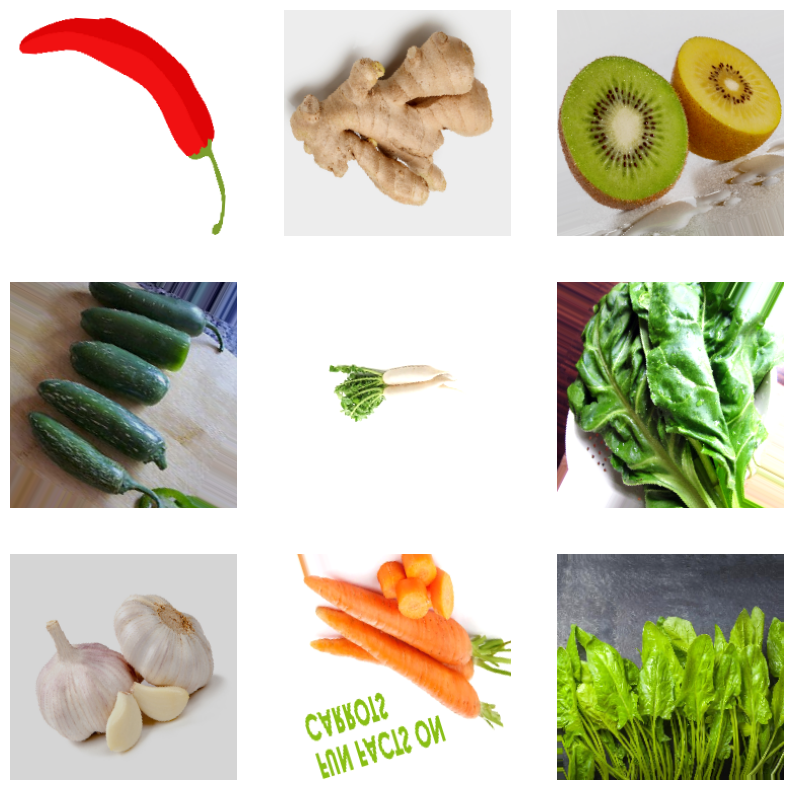

In [ ]:
image, labels = next(train_generator)
plt.figure(figsize=(10, 10))

for i in range(9):
  plt.subplot(3, 3, i+1)
  plt.imshow(image[i])
  plt.axis('off')

plt.show()

Baseline CNN Model

Architecture:

Conv -> ReLU -> Pool

Conv -> ReLU -> Pool

Conv -> ReLU -> Pool

Dense -> Softmax

CNN Model from scratch

In [ ]:
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation = 'relu', input_shape=(224, 224, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3,3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3,3), activation = 'relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile the model

In [ ]:
baseline_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

Model Training

In [19]:
history_baseline = baseline_model.fit(train_generator, validation_data=val_generator, epochs = 10)

Epoch 1/10
 9/98 ━━━━━━━━━━━━━━━━━━━━ 1:33 1s/step - accuracy: 0.0495 - loss: 4.6969   

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.0491 - loss: 3.5651 - val_accuracy: 0.0741 - val_loss: 3.2254
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.0812 - loss: 3.2697 - val_accuracy: 0.1681 - val_loss: 2.8750
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.1361 - loss: 3.0150 - val_accuracy: 0.2792 - val_loss: 2.4876
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.1807 - loss: 2.8009 - val_accuracy: 0.3077 - val_loss: 2.3480
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.1884 - loss: 2.7120 - val_accuracy: 0.4302 - val_loss: 2.1346
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.1987 - loss: 2.6269 - val_accuracy: 0.3960 - val_loss: 2.0951
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.2433 - loss: 2.5299 - val_accuracy: 0.4302 - val_loss: 1.8933
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.2520 - loss: 2.4555 - val_accuracy: 0.4701 - val_loss: 1.

Transfer Learning

In [21]:
base_model = MobileNetV2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)

for layer in base_model.layers:
  layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256,activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)

predictions = Dense(train_generator.num_classes,activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


In [24]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
history_transfer = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
 6/98 ━━━━━━━━━━━━━━━━━━━━ 1:41 1s/step - accuracy: 0.0627 - loss: 3.7775

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


98/98 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.3990 - loss: 2.2383 - val_accuracy: 0.8348 - val_loss: 0.6797
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.6424 - loss: 1.1681 - val_accuracy: 0.8832 - val_loss: 0.4374
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7008 - loss: 0.9348 - val_accuracy: 0.9003 - val_loss: 0.3421
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7538 - loss: 0.7899 - val_accuracy: 0.8917 - val_loss: 0.3410
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7653 - loss: 0.7226 - val_accuracy: 0.9174 - val_loss: 0.2807
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7833 - loss: 0.6664 - val_accuracy: 0.8974 - val_loss: 0.2921
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8022 - loss: 0.6092 - val_accuracy: 0.9145 - val_loss: 0.2601
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.8125 - loss: 0.5581 - val_accuracy: 0.9231 - val_loss: 0.

Confusion Matrix

In [26]:
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions,axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true,y_pred)

print(cm)

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
[[ 9  0  0 ...  0  0  0]
 [ 0  7  0 ...  0  0  0]
 [ 0  0 10 ...  0  0  0]
 ...
 [ 0  0  0 ... 10  0  0]
 [ 0  0  0 ...  0  8  0]
 [ 0  0  0 ...  0  0 10]]
